In [1]:
import os
import certifi

os.environ['REQUESTS_CA_BUNDLE'] = certifi.where()
os.environ['SSL_CERT_FILE'] = certifi.where()

In [2]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', 100)

In [3]:
import sportsdataverse as sdv

wnba_data = sdv.wnba.load_wnba_team_boxscore(seasons=[2023], return_as_pandas=True)
print("Data loaded successfully!")

100%|██████████| 1/1 [00:00<00:00,  1.60it/s]

Data loaded successfully!


In [4]:
#wnba_data.head()

In [5]:
#wnba_data.info()

In [6]:
#wnba_data.head(1)

In [7]:
from sportsdataverse.wnba import load_wnba_pbp

pbp = load_wnba_pbp(seasons=2026, return_as_pandas=True)

# filter out non-regular season games immediately after loading
EXCLUDE_GAMES = [401857321, 401857320]  # Commissioner's Cup, All-Star
pbp = pbp[~pbp['game_id'].astype(int).isin(EXCLUDE_GAMES)]

print(f"Rows after filtering: {pbp.shape}")

100%|██████████| 1/1 [00:00<00:00,  2.14it/s]

Rows after filtering: (122592, 67)


In [8]:
pbp.head(5)
pbp.info()

<class 'pandas.DataFrame'>
Index: 122592 entries, 0 to 123454
Data columns (total 67 columns):
 #   Column                           Non-Null Count   Dtype                                      
---  ------                           --------------   -----                                      
 0   game_play_number                 122592 non-null  int32[pyarrow]                             
 1   id                               122592 non-null  int64[pyarrow]                             
 2   sequence_number                  122592 non-null  int32[pyarrow]                             
 3   type_id                          122592 non-null  int32[pyarrow]                             
 4   type_text                        122592 non-null  large_string[pyarrow]                      
 5   text                             122590 non-null  large_string[pyarrow]                      
 6   away_score                       122592 non-null  int32[pyarrow]                             
 7   home_scor

In [9]:
## Play Types

pbp.info()
with pd.option_context('display.max_rows', None):
    display(pbp[['type_id','type_text']].drop_duplicates().sort_values('type_id', ascending=True))
# looking for unique play types to sort into buckets
# making a new feature for my play type buckets
conditions = [
    (pbp['type_id'] >= 62) & (pbp['type_id'] <= 90),
    ((pbp['type_id'] >= 91) & (pbp['type_id'] <= 148)) | (pbp['type_id'].isin([157, 165, 166]))
]

choices = [
    'turnover',
    'score'
]

pbp['play_category'] = np.select(conditions, choices, default='ignore')

<class 'pandas.DataFrame'>
Index: 122592 entries, 0 to 123454
Data columns (total 67 columns):
 #   Column                           Non-Null Count   Dtype                                      
---  ------                           --------------   -----                                      
 0   game_play_number                 122592 non-null  int32[pyarrow]                             
 1   id                               122592 non-null  int64[pyarrow]                             
 2   sequence_number                  122592 non-null  int32[pyarrow]                             
 3   type_id                          122592 non-null  int32[pyarrow]                             
 4   type_text                        122592 non-null  large_string[pyarrow]                      
 5   text                             122590 non-null  large_string[pyarrow]                      
 6   away_score                       122592 non-null  int32[pyarrow]                             
 7   home_scor

,type_id,type_text
126,8,Delay of Game
5629,10,Lane
346,11,Jump Ball
480,12,Kicked Ball
62646,13,Double Lane
69988,15,No Timeout
43,16,Full Timeout
143,19,Official Timeout
373,22,Personal Take Foul
428,24,Offensive Charge


In [10]:
# Single Game Investigation

pbp['game_id']
with pd.option_context('display.max_rows', None):
    display(pbp.query('game_id == "401857060"').sort_values('game_play_number', ascending=True))

,game_play_number,id,sequence_number,type_id,type_text,text,away_score,home_score,period_number,period_display_value,clock_display_value,scoring_play,score_value,team_id,athlete_id_1,athlete_id_2,athlete_id_3,wallclock,shooting_play,coordinate_x_raw,coordinate_y_raw,points_attempted,short_description,game_id,season,season_type,home_team_id,home_team_name,home_team_mascot,home_team_abbrev,home_team_name_alt,away_team_id,away_team_name,away_team_mascot,away_team_abbrev,away_team_name_alt,game_spread,home_favorite,game_spread_available,home_team_spread,qtr,time,clock_minutes,clock_seconds,home_timeout_called,away_timeout_called,half,game_half,lag_qtr,lead_qtr,lag_half,lead_half,start_quarter_seconds_remaining,start_half_seconds_remaining,start_game_seconds_remaining,end_quarter_seconds_remaining,end_half_seconds_remaining,end_game_seconds_remaining,period,coordinate_x,coordinate_y,game_date,game_date_time,athlete_name_1,athlete_name_2,athlete_name_3,type_abbreviation,play_category
51166,1,4018570604,4,615,Jumpball,Jonquel Jones vs. Isabelle Harrison (Julie All...,0,0,1,1st Quarter,10:00,False,0,131935,2566453,2999101,4001679,2026-07-12T19:03:03Z,False,-214748340.0,-214748365.0,0,Jump Ball,401857060,2026,2,131935,Toronto,Tempo,TOR,Toronto,9,New York,Liberty,NY,New York,2.5,True,False,2.5,1,10:00,10,0.0,False,False,1,1,<NA>,1,<NA>,1,600.0,1200.0,2400.0,600.0,1200.0,2400.0,1,214748406.75,214748365.0,2026-07-12,2026-07-12 15:00:00-04:00,Isabelle Harrison,Jonquel Jones,Julie Allemand,<NA>,ignore
51167,2,4018570608,8,45,Personal Foul,Pauline Astier personal foul,0,0,1,1st Quarter,9:47,False,0,9,5345320,<NA>,<NA>,2026-07-12T19:03:18Z,False,14.0,12.0,0,Foul,401857060,2026,2,131935,Toronto,Tempo,TOR,Toronto,9,New York,Liberty,NY,New York,2.5,True,False,2.5,1,9:47,9,47.0,False,False,1,1,1,1,1,1,587.0,1187.0,2387.0,580.0,1180.0,2380.0,1,-29.75,-11.0,2026-07-12,2026-07-12 15:00:00-04:00,Pauline Astier,<NA>,<NA>,<NA>,ignore
51168,3,40185706010,10,92,Jump Shot,Marina Mabrey misses 25-foot three point jumper,0,0,1,1st Quarter,9:40,False,0,131935,3904576,<NA>,<NA>,2026-07-12T19:03:27Z,True,40.0,20.0,3,Missed 3PT,401857060,2026,2,131935,Toronto,Tempo,TOR,Toronto,9,New York,Liberty,NY,New York,2.5,True,False,2.5,1,9:40,9,40.0,False,False,1,1,1,1,1,1,580.0,1180.0,2380.0,577.0,1177.0,2377.0,1,21.75,-15.0,2026-07-12,2026-07-12 15:00:00-04:00,Marina Mabrey,<NA>,<NA>,<NA>,score
51169,4,40185706011,11,155,Defensive Rebound,Pauline Astier defensive rebound,0,0,1,1st Quarter,9:37,False,0,9,5345320,<NA>,<NA>,2026-07-12T19:03:30Z,False,40.0,20.0,0,Rebound,401857060,2026,2,131935,Toronto,Tempo,TOR,Toronto,9,New York,Liberty,NY,New York,2.5,True,False,2.5,1,9:37,9,37.0,False,False,1,1,1,1,1,1,577.0,1177.0,2377.0,557.0,1157.0,2357.0,1,-21.75,15.0,2026-07-12,2026-07-12 15:00:00-04:00,Pauline Astier,<NA>,<NA>,<NA>,ignore
51170,5,40185706012,12,70,Shot Clock Turnover,shot clock turnover,0,0,1,1st Quarter,9:17,False,0,9,<NA>,<NA>,<NA>,2026-07-12T19:03:53Z,False,9.0,23.0,0,Turnover,401857060,2026,2,131935,Toronto,Tempo,TOR,Toronto,9,New York,Liberty,NY,New York,2.5,True,False,2.5,1,9:17,9,17.0,False,False,1,1,1,1,1,1,557.0,1157.0,2357.0,543.0,1143.0,2343.0,1,-18.75,-16.0,2026-07-12,2026-07-12 15:00:00-04:00,<NA>,<NA>,<NA>,<NA>,turnover
51171,6,40185706013,13,128,Driving Finger Roll Layup,Han Xu blocks Marina Mabrey 's 6-foot two poin...,0,0,1,1st Quarter,9:03,False,0,131935,3904576,4337216,<NA>,2026-07-12T19:04:32Z,True,28.0,5.0,2,Missed FG,401857060,2026,2,131935,Toronto,Tempo,TOR,Toronto,9,New York,Liberty,NY,New York,2.5,True,False,2.5,1,9:03,9,3.0,False,False,1,1,1,1,1,1,543.0,1143.0,2343.0,543.0,1143.0,2343.0,1,36.75,-3.0,2026-07-12,2026-07-12 15:00:00-04:00,Marina Mabrey,Han Xu,<NA>,<NA>,score
51172,7,40185706015,15,156,Offensive Rebound,Tempo offensive team rebound,0,0,1,1st Quarter,9:03,False,0,131935,<NA>,<NA>,<NA>,2026-07-12T19:04:32Z,False,28.0,5.0,0,Rebound,401857060,2026,2,131935,Toronto,Tempo,TOR,Toronto,9,New York,Liberty,NY,New York,2.5,True,False,2

In [11]:
## making a time elapsed feature
pbp['elapsed_time_minutes'] = (pbp['period_number'] - 1) * 10 + (10 - pbp['clock_minutes'] - (pbp['clock_seconds'] / 60))
## tracking which points went to home vs away per scoring play
pbp['home_points'] = np.where(pbp['scoring_play'] & (pbp['team_id'] == pbp['home_team_id']), pbp['score_value'], 0)
pbp['away_points'] = np.where(pbp['scoring_play'] & (pbp['team_id'] != pbp['home_team_id']), pbp['score_value'], 0)
pbp['net_points'] = pbp['home_points'] - pbp['away_points']

In [12]:
pbp = pbp.reset_index(drop=True)
scoring_only = pbp[pbp['play_category'] == 'score'].copy()
scoring_only = scoring_only.sort_values(['game_id', 'elapsed_time_minutes'])
scoring_only = scoring_only.set_index('elapsed_time_minutes')

scoring_only['momentum'] = (
    scoring_only.groupby('game_id')['net_points']
    .rolling(window=8, min_periods=1)
    .sum()
    .reset_index(level=0, drop=True)
)

In [13]:
with pd.option_context('display.max_rows', None):
    display(scoring_only.query('game_id == "401857060"').sort_values('game_play_number', ascending=True)[['momentum', 'net_points', 'home_points', 'away_points']])

,momentum,net_points,home_points,away_points
elapsed_time_minutes,,,,
0.333333,0.0,0,0,0
0.95,0.0,0,0,0
1.133333,0.0,0,0,0
1.383333,0.0,0,0,0
1.5,3.0,3,3,0
1.916667,0.0,-3,0,3
2.083333,3.0,3,3,0
2.416667,3.0,0,0,0
2.45,3.0,0,0,0


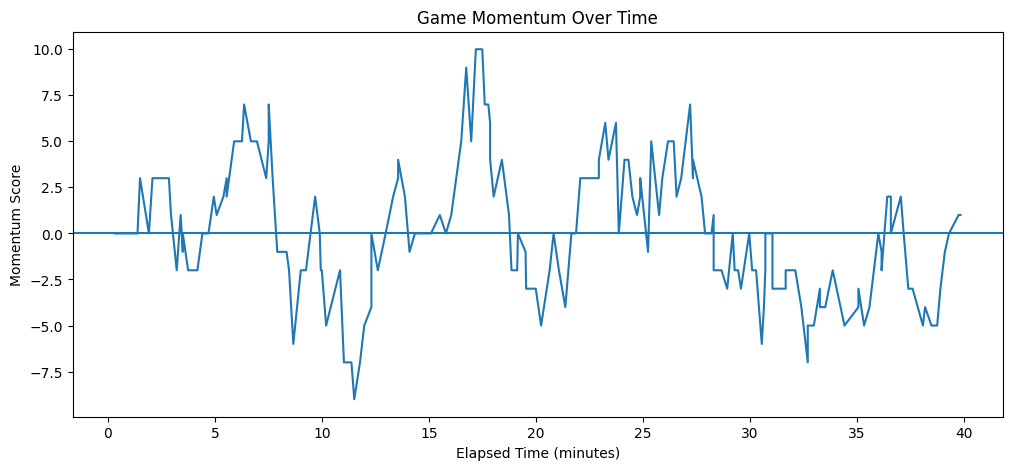

In [14]:
import matplotlib.pyplot as plt

game = scoring_only[scoring_only['game_id'] == 401857060]

plt.figure(figsize=(12, 5))
plt.plot(game.index, game['momentum'])
plt.axhline(y=0)
plt.title('Game Momentum Over Time')
plt.xlabel('Elapsed Time (minutes)')
plt.ylabel('Momentum Score')
plt.show()

In [15]:
pbp[pbp['home_team_name'].str.contains('New York', na=False)]['home_team_id'].unique()

<ArrowExtensionArray>
[9]
Length: 1, dtype: int32[pyarrow]

In [16]:
liberty_games = pbp[(pbp['home_team_id'] == 9) | (pbp['away_team_id'] == 9)]
liberty_game_ids = liberty_games['game_id'].unique()
liberty_game_ids = liberty_game_ids[liberty_game_ids != 401857321]
print(len(liberty_game_ids))

40


In [17]:
liberty_schedule = liberty_games.groupby('game_id').agg(
    home_team_id=('home_team_id', 'first'),
    away_team_id=('away_team_id', 'first'),
    game_date=('game_date', 'first')
).reset_index().sort_values('game_date')

liberty_schedule = liberty_schedule[liberty_schedule['game_id'] != 401857321]
print(liberty_schedule)

      game_id  home_team_id  away_team_id   game_date
0   401856890             9            18  2026-05-08
1   401856897            16             9  2026-05-10
2   401856903        132052             9  2026-05-12
3   401856909        132052             9  2026-05-14
4   401856924             9        129689  2026-05-21
5   401856934             9             3  2026-05-24
6   401856936             9        132052  2026-05-25
7   401856938             9            11  2026-05-27
8   401856945             9            11  2026-05-29
9   401856959             9        131935  2026-06-03
10  401856969             9             5  2026-06-06
11  401856972            18             9  2026-06-08
12  401856981            20             9  2026-06-11
13  401856990             9            16  2026-06-14
14  401856997            19             9  2026-06-17
15  401857004             9            16  2026-06-19
16  401857011             6             9  2026-06-21
17  401857016            17 

In [18]:
liberty_pbp = pbp[pbp['game_id'].isin(liberty_game_ids)]

In [19]:
def calculate_team_momentum(pbp, team_search, window=8):
    
    # 1. filter to team games
    team_games = pbp[
        (pbp['home_team_name'].str.contains(team_search, case=False, na=False)) |
        (pbp['away_team_name'].str.contains(team_search, case=False, na=False)) |
        (pbp['home_team_mascot'].str.contains(team_search, case=False, na=False)) |
        (pbp['away_team_mascot'].str.contains(team_search, case=False, na=False))
    ].copy()
    
    print(f"games found: {len(team_games)}")

    # get team name for title
    match_home = team_games[
        team_games['home_team_name'].str.contains(team_search, case=False, na=False) |
        team_games['home_team_mascot'].str.contains(team_search, case=False, na=False)
    ]
    if len(match_home) > 0:
        team_name = match_home['home_team_name'].iloc[0] + ' ' + match_home['home_team_mascot'].iloc[0]
    else:
        match_away = team_games[
            team_games['away_team_name'].str.contains(team_search, case=False, na=False) |
            team_games['away_team_mascot'].str.contains(team_search, case=False, na=False)
        ]
        team_name = match_away['away_team_name'].iloc[0] + ' ' + match_away['away_team_mascot'].iloc[0]
    
    # 2. categorize play types
    conditions = [
        (team_games['type_id'] >= 62) & (team_games['type_id'] <= 90),
        ((team_games['type_id'] >= 91) & (team_games['type_id'] <= 148)) | 
        (team_games['type_id'].isin([157, 165, 166]))
    ]
    choices = ['turnover', 'score']
    team_games['play_category'] = np.select(conditions, choices, default='ignore')
    
    # 3. calculate elapsed time
    team_games['elapsed_time_minutes'] = (
        (team_games['period_number'] - 1) * 10 + 
        (10 - team_games['clock_minutes'] - (team_games['clock_seconds'] / 60))
    )
    
    # 4. calculate net points from team perspective
    team_games['home_points'] = np.where(
        (team_games['play_category'] == 'score') & (team_games['team_id'] == team_games['home_team_id']),
        team_games['score_value'], 0
    )
    team_games['away_points'] = np.where(
        (team_games['play_category'] == 'score') & (team_games['team_id'] != team_games['home_team_id']),
        team_games['score_value'], 0
    )
    team_games['team_net_points'] = np.where(
        team_games['home_team_name'].str.contains(team_search, case=False, na=False) |
        team_games['home_team_mascot'].str.contains(team_search, case=False, na=False),
        team_games['home_points'] - team_games['away_points'],
        team_games['away_points'] - team_games['home_points']
    )
    
    # 5. filter to scoring plays
    scoring = team_games[team_games['play_category'] == 'score'].copy()
    scoring = scoring.sort_values(['game_id', 'elapsed_time_minutes'])
    scoring = scoring.set_index('elapsed_time_minutes')
    
    # 6. calculate rolling momentum
    scoring['momentum'] = (
        scoring.groupby('game_id')['team_net_points']
        .rolling(window=window, min_periods=1)
        .sum()
        .reset_index(level=0, drop=True)
    )
    
    # momentum fingerprint
    scoring['time_bucket'] = scoring.index.round(0)
    fingerprint = scoring.groupby('time_bucket')['momentum'].mean()
    fingerprint = fingerprint[fingerprint.index <= 40]

    plt.figure(figsize=(14, 6))
    plt.plot(fingerprint.index, fingerprint.values)
    plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    plt.axvline(x=10, color='grey', linestyle='--', alpha=0.3)
    plt.axvline(x=20, color='grey', linestyle='--', alpha=0.3)
    plt.axvline(x=30, color='grey', linestyle='--', alpha=0.3)
    plt.axvline(x=40, color='grey', linestyle='--', alpha=0.3)
    plt.title(f'{team_name} Average Momentum — 2026 Season')
    plt.xlabel('Elapsed Time (minutes)')
    plt.ylabel('Average Momentum Score')
    plt.show()
    
    return scoring

games found: 15706


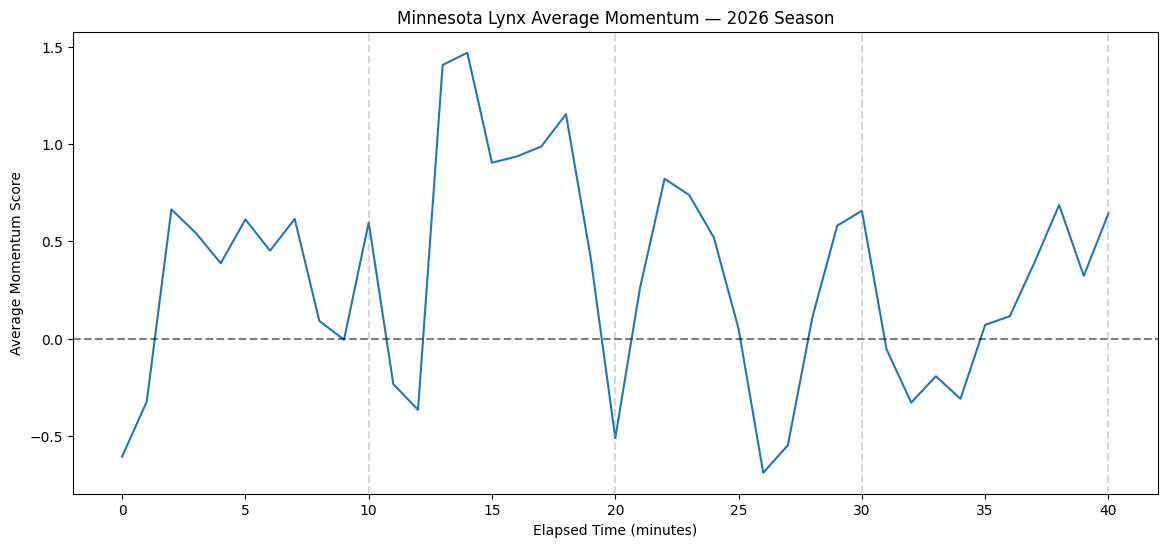

,game_play_number,id,sequence_number,type_id,type_text,text,away_score,home_score,period_number,period_display_value,clock_display_value,scoring_play,score_value,team_id,athlete_id_1,athlete_id_2,athlete_id_3,wallclock,shooting_play,coordinate_x_raw,coordinate_y_raw,points_attempted,short_description,game_id,season,season_type,home_team_id,home_team_name,home_team_mascot,home_team_abbrev,home_team_name_alt,away_team_id,away_team_name,away_team_mascot,away_team_abbrev,away_team_name_alt,game_spread,home_favorite,game_spread_available,home_team_spread,qtr,time,clock_minutes,clock_seconds,home_timeout_called,away_timeout_called,half,game_half,lag_qtr,lead_qtr,lag_half,lead_half,start_quarter_seconds_remaining,start_half_seconds_remaining,start_game_seconds_remaining,end_quarter_seconds_remaining,end_half_seconds_remaining,end_game_seconds_remaining,period,coordinate_x,coordinate_y,game_date,game_date_time,athlete_name_1,athlete_name_2,athlete_name_3,type_abbreviation,play_category,home_points,away_points,net_points,team_net_points,momentum,time_bucket
elapsed_time_minutes,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0.3,3,4018568999,9,113,Running Jump Shot,Nia Coffey makes 22-foot running jump shot (Ol...,0,3,1,1st Quarter,9:42,True,3,8,3054590,4433791,<NA>,2026-05-10T00:03:04Z,True,7.0,13.0,3,+3 Points,401856899,2026,2,8,Minnesota,Lynx,MIN,Minnesota,20,Atlanta,Dream,ATL,Atlanta,2.5,True,False,2.5,1,9:42,9,42.0,False,False,1,1,1,1,1,1,582.0,1182.0,2382.0,557.0,1157.0,2357.0,1,28.75,18.0,2026-05-09,2026-05-09 20:00:00-04:00,Nia Coffey,Olivia Miles,<NA>,<NA>,score,3,0,3,3,3.0,0.0
0.716667,4,40185689911,11,92,Jump Shot,Naz Hillmon misses 22-foot three point jumper,0,3,1,1st Quarter,9:17,False,0,20,4398915,<NA>,<NA>,2026-05-10T00:03:29Z,True,47.0,1.0,3,Missed 3PT,401856899,2026,2,8,Minnesota,Lynx,MIN,Minnesota,20,Atlanta,Dream,ATL,Atlanta,2.5,True,False,2.5,1,9:17,9,17.0,False,False,1,1,1,1,1,1,557.0,1157.0,2357.0,554.0,1154.0,2354.0,1,-40.75,22.0,2026-05-09,2026-05-09 20:00:00-04:00,Naz Hillmon,<NA>,<NA>,<NA>,score,0,0,0,0,3.0,1.0
0.85,6,40185689913,13,113,Running Jump Shot,Nia Coffey misses 22-foot running jump shot,0,3,1,1st Quarter,9:09,False,0,8,3054590,<NA>,<NA>,2026-05-10T00:03:38Z,True,4.0,7.0,3,Missed 3PT,401856899,2026,2,8,Minnesota,Lynx,MIN,Minnesota,20,Atlanta,Dream,ATL,Atlanta,2.5,True,False,2.5,1,9:09,9,9.0,False,False,1,1,1,1,1,1,549.0,1149.0,2349.0,546.0,1146.0,2346.0,1,34.75,21.0,2026-05-09,2026-05-09 20:00:00-04:00,Nia Coffey,<NA>,<NA>,<NA>,score,0,0,0,0,3.0,1.0
1.033333,8,40185689915,15,141,Cutting Layup Shot,Angel Reese misses layup,0,3,1,1st Quarter,8:58,False,0,20,4433402,<NA>,<NA>,2026-05-10T00:03:49Z,True,26.0,2.0,2,Missed FG,401856899,2026,2,8,Minnesota,Lynx,MIN,Minnesota,20,Atlanta,Dream,ATL,Atlanta,2.5,True,False,2.5,1,8:58,8,58.0,False,False,1,1,1,1,1,1,538.0,1138.0,2338.0,534.0,1134.0,2334.0,1,-39.75,1.0,2026-05-09,2026-05-09 20:00:00-04:00,Angel Reese,<NA>,<NA>,<NA>,score,0,0,0,0,3.0,1.0
1.116667,10,40185689917,17,92,Jump Shot,Allisha Gray misses 23-foot three point jumper,0,3,1,1st Quarter,8:53,False,0,20,3058901,<NA>,<NA>,2026-05-10T00:03:55Z,True,8.0,16.0,3,Missed 3PT,401856899,2026,2,8,Minnesota,Lynx,MIN,Minnesota,20,Atlanta,Dream,ATL,Atlanta,2.5,True,False,2.5,1,8:53,8,53.0,False,False,1,1,1,1,1,1,533.0,1133.0,2333.0,530.0,1130.0,2330.0,1,-25.75,-17.0,2026-05-09,2026-05-09 20:00:00-04:00,Allisha Gray,<NA>,<NA>,<NA>,score,0,0,0,0,3.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38.8,372,401857186548,548,114,Turnaround Jump Shot,Jordin Canada makes 8-foot turnaround jump shot,77,89,4,4th Quarter,1:12,True,2,20,3142250,<NA>,<NA>,2026-08-30T20:57:15Z,True,19.0,6.0,2,+2 Points,401857186,2026,2,20,Atlanta,Dream,ATL,Atlanta

In [20]:
calculate_team_momentum(pbp, 'Lynx')

games found: 16158


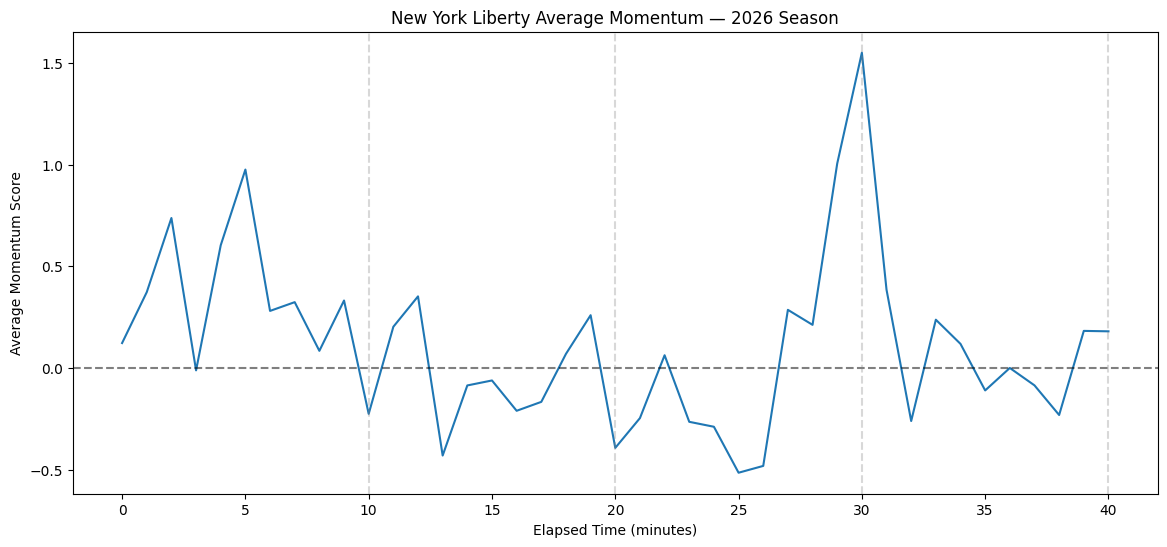

(7086, 74)


In [21]:
liberty_momentum = calculate_team_momentum(pbp, 'Liberty')
print(liberty_momentum.shape)

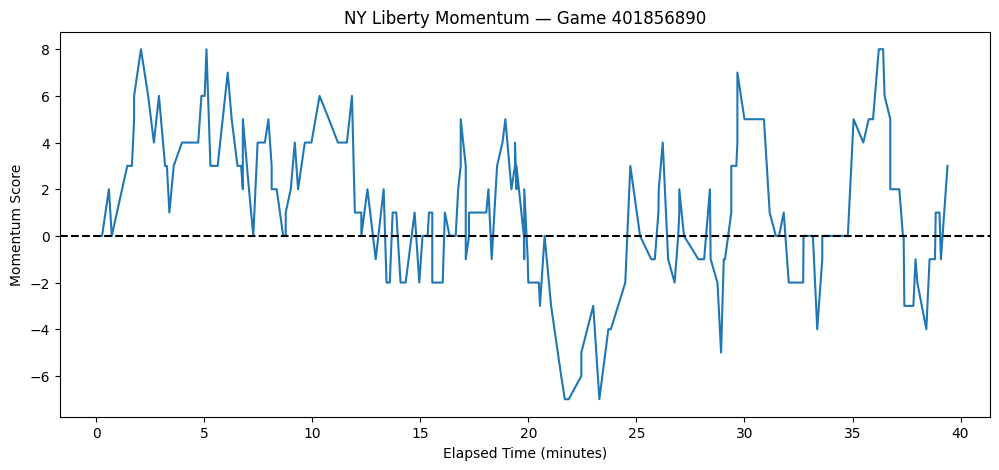

In [22]:
game = liberty_momentum[liberty_momentum['game_id'] == 401856890]

plt.figure(figsize=(12, 5))
plt.plot(game.index, game['momentum'])
plt.axhline(y=0, color='black', linestyle='--')
plt.title('NY Liberty Momentum — Game 401856890')
plt.xlabel('Elapsed Time (minutes)')
plt.ylabel('Momentum Score')
plt.show()

In [23]:
print(liberty_schedule[liberty_schedule['game_id'] == 401856890]) # sanity check

     game_id  home_team_id  away_team_id   game_date
0  401856890             9            18  2026-05-08


In [24]:
liberty_momentum['time_bucket'] = liberty_momentum.index.round(0)
fingerprint = liberty_momentum.groupby('time_bucket')['momentum'].mean()
fingerprint = fingerprint[fingerprint.index <= 40]

In [25]:
print(fingerprint)

time_bucket
0.0     0.122449
1.0     0.372671
2.0     0.737143
3.0    -0.011834
4.0     0.603352
5.0     0.975309
6.0     0.280488
7.0     0.323529
8.0     0.084211
9.0     0.331579
10.0   -0.225610
11.0    0.202532
12.0    0.351955
13.0   -0.430464
14.0   -0.085890
15.0   -0.061453
16.0   -0.210526
17.0   -0.166667
18.0    0.069307
19.0    0.259434
20.0   -0.392857
21.0   -0.246479
22.0    0.062500
23.0   -0.264706
24.0   -0.289017
25.0   -0.514970
26.0   -0.481481
27.0    0.285714
28.0    0.211957
29.0    1.004695
30.0    1.549708
31.0    0.384615
32.0   -0.260870
33.0    0.237288
34.0    0.118343
35.0   -0.110429
36.0    0.000000
37.0   -0.085526
38.0   -0.231214
39.0    0.182243
40.0    0.180124
Name: momentum, dtype: float64


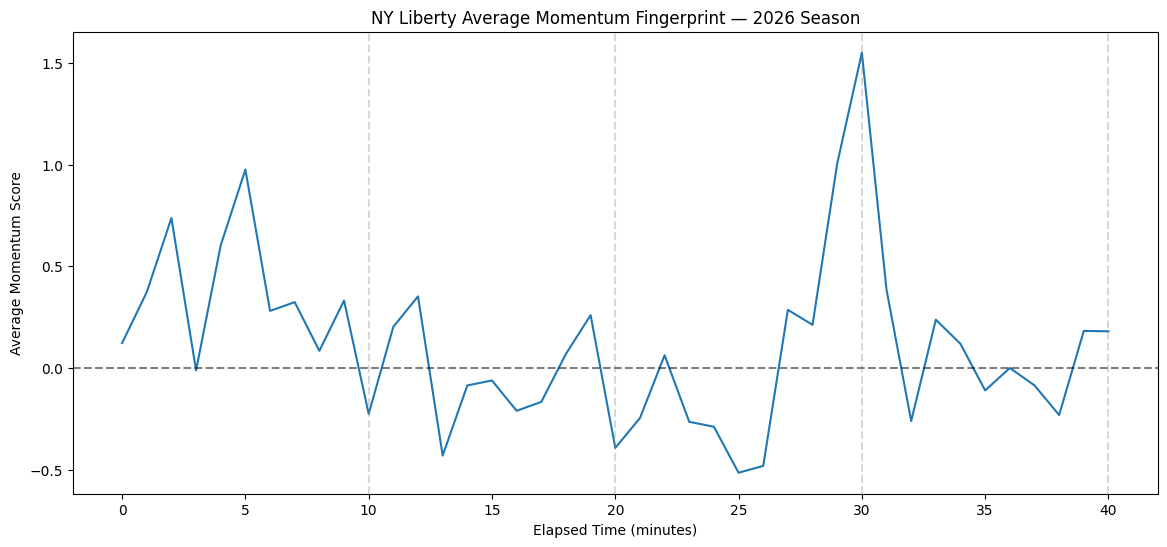

In [26]:
plt.figure(figsize=(14, 6))
plt.plot(fingerprint.index, fingerprint.values)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.axvline(x=10, color='grey', linestyle='--', alpha=0.3)
plt.axvline(x=20, color='grey', linestyle='--', alpha=0.3)
plt.axvline(x=30, color='grey', linestyle='--', alpha=0.3)
plt.axvline(x=40, color='grey', linestyle='--', alpha=0.3)
plt.title('NY Liberty Average Momentum Fingerprint — 2026 Season')
plt.xlabel('Elapsed Time (minutes)')
plt.ylabel('Average Momentum Score')
plt.show()

In [27]:
team_lookup = pbp[['home_team_id', 'home_team_name', 'away_team_id']].drop_duplicates().sort_values('home_team_id')
print(team_lookup)

        home_team_id home_team_name  away_team_id
1186               3         Dallas            18
5932               3         Dallas        132052
7469               3         Dallas            14
11446              3         Dallas             5
20062              3         Dallas        131935
...              ...            ...           ...
91908         132052       Portland            11
99235         132052       Portland            20
101644        132052       Portland            18
114592        132052       Portland             9
120819        132052       Portland            19

[204 rows x 3 columns]


games found: 16522


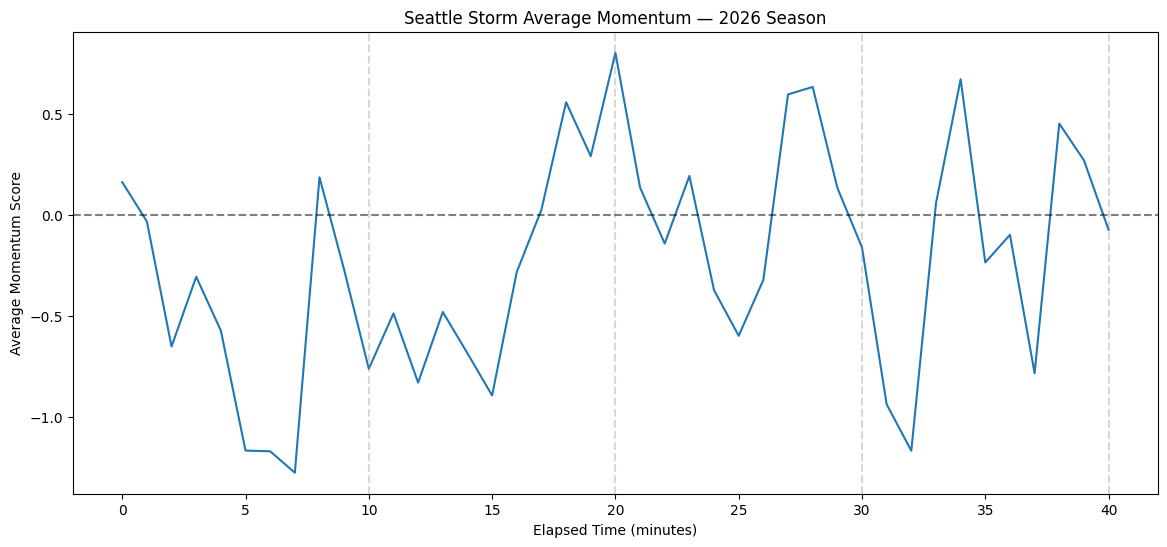

(7255, 74)


In [28]:
storm_momentum = calculate_team_momentum(pbp, 'Seattle')
print(storm_momentum.shape)

In [29]:
# testing variables for the coordinates 
print(pbp[['coordinate_x_raw', 'coordinate_y_raw', 'shooting_play']].dropna().shape) # grab the 3 cols and get the shape

(122592, 3)


In [30]:
print(pbp[pbp['shooting_play'] == True][['coordinate_x_raw', 'coordinate_y_raw', 'type_text']].head(20))

    coordinate_x_raw  coordinate_y_raw                        type_text
2               24.0               1.0                        Hook Shot
3               23.0               2.0               Driving Layup Shot
5               44.0              18.0                        Jump Shot
6               27.0               1.0               Driving Layup Shot
10              25.0             13.75              Free Throw - 1 of 2
11              25.0             13.75              Free Throw - 2 of 2
12              25.0               1.0            Layup Driving Reverse
13              48.0               1.0                        Jump Shot
15              14.0              15.0                 Pullup Jump Shot
17               5.0               1.0                        Jump Shot
19              44.0              19.0                Running Jump Shot
20              29.0               1.0  Driving Floating Bank Jump Shot
23              23.0               1.0               Running Lay

In [31]:
shots = pbp[
    (pbp['shooting_play'] == True) & 
    (~pbp['type_text'].str.contains('Free Throw', na=False))
][['coordinate_x_raw', 'coordinate_y_raw', 'scoring_play', 'type_text']]

print(shots)

        coordinate_x_raw  coordinate_y_raw scoring_play  \
2                   24.0               1.0         True   
3                   23.0               2.0         True   
5                   44.0              18.0         True   
6                   27.0               1.0        False   
12                  25.0               1.0         True   
...                  ...               ...          ...   
122563              26.0               1.0         True   
122564              21.0              10.0         True   
122568              28.0               1.0         True   
122575              20.0              10.0         True   
122584              37.0              22.0        False   

                             type_text  
2                            Hook Shot  
3                   Driving Layup Shot  
5                            Jump Shot  
6                   Driving Layup Shot  
12               Layup Driving Reverse  
...                                ...  
1225

In [32]:
# cite : http://savvastjortjoglou.com/nba-shot-sharts.html

from matplotlib.patches import Circle, Rectangle, Arc

def draw_court(ax=None, color='black', lw=2, outer_lines=False):
    # If an axes object isn't provided to plot onto, just get current one
    if ax is None:
        ax = plt.gca()

    # Create the various parts of an NBA basketball court

    # Create the basketball hoop
    # Diameter of a hoop is 18" so it has a radius of 9", which is a value
    # 7.5 in our coordinate system
    hoop = Circle((0, 0), radius=7.5, linewidth=lw, color=color, fill=False)

    # Create backboard
    backboard = Rectangle((-30, -7.5), 60, -1, linewidth=lw, color=color)

    # The paint
    # Create the outer box 0f the paint, width=16ft, height=19ft
    outer_box = Rectangle((-80, -47.5), 160, 190, linewidth=lw, color=color,
                          fill=False)
    # Create the inner box of the paint, widt=12ft, height=19ft
    inner_box = Rectangle((-60, -47.5), 120, 190, linewidth=lw, color=color,
                          fill=False)

    # Create free throw top arc
    top_free_throw = Arc((0, 142.5), 120, 120, theta1=0, theta2=180,
                         linewidth=lw, color=color, fill=False)
    # Create free throw bottom arc
    bottom_free_throw = Arc((0, 142.5), 120, 120, theta1=180, theta2=0,
                            linewidth=lw, color=color, linestyle='dashed')
    # Restricted Zone, it is an arc with 4ft radius from center of the hoop
    restricted = Arc((0, 0), 80, 80, theta1=0, theta2=180, linewidth=lw,
                     color=color)

    # Three point line
    # Create the side 3pt lines, they are 14ft long before they begin to arc
    corner_three_a = Rectangle((-220, -47.5), 0, 140, linewidth=lw,
                               color=color)
    corner_three_b = Rectangle((220, -47.5), 0, 140, linewidth=lw, color=color)
    # 3pt arc - center of arc will be the hoop, arc is 23'9" away from hoop
    # I just played around with the theta values until they lined up with the 
    # threes
    three_arc = Arc((0, 0), 475, 475, theta1=22, theta2=158, linewidth=lw,
                    color=color)

    # Center Court
    center_outer_arc = Arc((0, 422.5), 120, 120, theta1=180, theta2=0,
                           linewidth=lw, color=color)
    center_inner_arc = Arc((0, 422.5), 40, 40, theta1=180, theta2=0,
                           linewidth=lw, color=color)

    # List of the court elements to be plotted onto the axes
    court_elements = [hoop, backboard, outer_box, inner_box, top_free_throw,
                      bottom_free_throw, restricted, corner_three_a,
                      corner_three_b, three_arc, center_outer_arc,
                      center_inner_arc]

    if outer_lines:
        # Draw the half court line, baseline and side out bound lines
        outer_lines = Rectangle((-250, -47.5), 500, 470, linewidth=lw,
                                color=color, fill=False)
        court_elements.append(outer_lines)

    # Add the court elements onto the axes
    for element in court_elements:
        ax.add_patch(element)

    return ax

In [33]:
shots_chart = pbp[
    (pbp['shooting_play'] == True) & 
    (~pbp['type_text'].str.contains('Free Throw', na=False)) & 
    (pbp['coordinate_y_raw'] <= 35) &
    (pbp['scoring_play'] == True) & 
    (pbp['athlete_name_1'] == "Marine Johannes")
][['coordinate_x_raw', 'coordinate_y_raw', 'scoring_play', 'type_text']]

print(shots_chart.shape)

(108, 4)


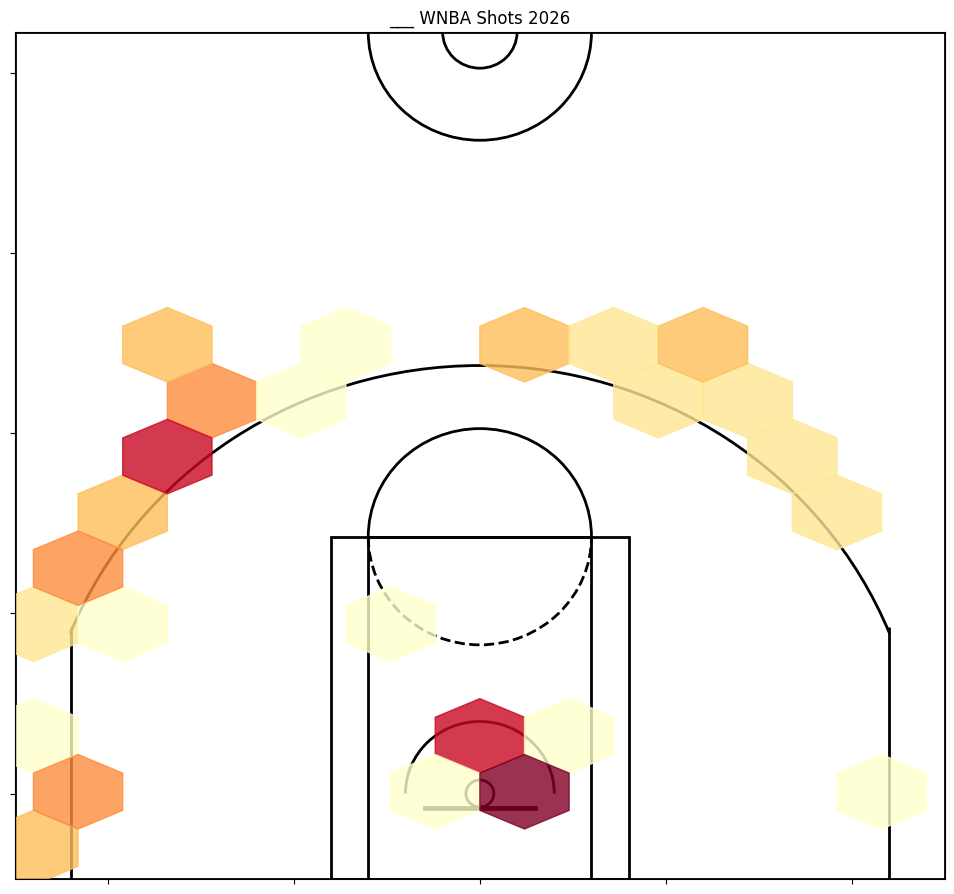

In [ ]:
shots_chart['x'] = (shots_chart['coordinate_x_raw'] - 25) * 10
shots_chart['y'] = shots_chart['coordinate_y_raw'] * 10

# filter out half court shots
shots_chart_filtered = shots_chart[shots_chart['y'] <= 300]

# then plot using shots_chart_filtered instead of shots_chart
fig, ax = plt.subplots(figsize=(12, 11))
draw_court(ax, outer_lines=True)
ax.hexbin(
    shots_chart_filtered['x'],
    shots_chart_filtered['y'],
    gridsize=10,
    cmap='YlOrRd',
    alpha=0.8,
    mincnt=2
)
ax.set_xlim(-250, 250)
ax.set_ylim(-47.5, 422.5)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(labelbottom=False, labelleft=False)
ax.set_title('___ WNBA Shots 2026')
plt.show()

In [35]:
def plot_shot_chart(pbp, player_name, made_only=True):
    shots = pbp[
        (pbp['shooting_play'] == True) & 
        (~pbp['type_text'].str.contains('Free Throw', na=False)) &
        (pbp['athlete_name_1'] == player_name)
    ].copy()
    
    if made_only:
        shots = shots[shots['scoring_play'] == True]
    
    shots['x'] = (shots['coordinate_x_raw'] - 25) * 10
    shots['y'] = shots['coordinate_y_raw'] * 10
    shots = shots[shots['y'] <= 300]
    
    fig, ax = plt.subplots(figsize=(12, 11))
    fig.patch.set_facecolor('#f8f8f8')
    ax.set_facecolor('#f8f8f8')
    
    ax.hexbin(shots['x'], shots['y'],
              gridsize=15, cmap='Blues',
              alpha=1.0, mincnt=1)
        
    # court drawn ON TOP of hexagons
    draw_court(ax, color='black', outer_lines=True)
    
    ax.set_xlim(-250, 250)
    ax.set_ylim(-47.5, 422.5)
    ax.set_axis_off()
    
    shot_type = "Made Field Goals" if made_only else "Field Goal Attempts"
    ax.set_title(f'{player_name}\n{shot_type} — 2026 WNBA Season',
                 fontsize=16, pad=20)
    
    ax.text(-240, 400, 'Data: ESPN via sportsdataverse',
            color='grey', fontsize=9)
    
    plt.tight_layout()
    plt.show()

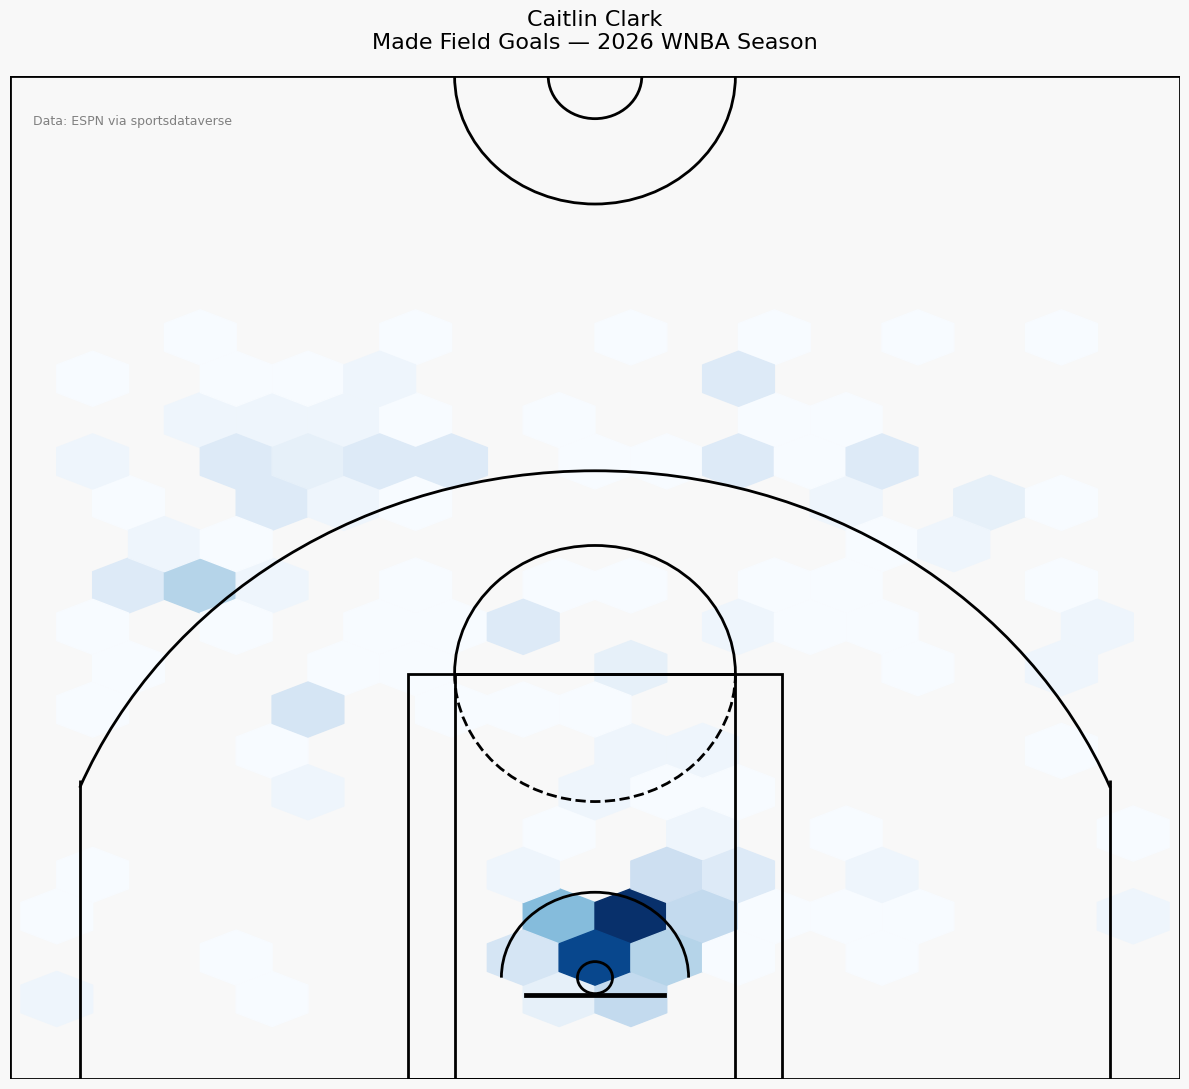

In [36]:
plot_shot_chart(pbp, "Caitlin Clark")

In [37]:
print(pbp['game_date'].max())
pbp.info()

2026-08-30
<class 'pandas.DataFrame'>
RangeIndex: 122592 entries, 0 to 122591
Data columns (total 72 columns):
 #   Column                           Non-Null Count   Dtype                                      
---  ------                           --------------   -----                                      
 0   game_play_number                 122592 non-null  int32[pyarrow]                             
 1   id                               122592 non-null  int64[pyarrow]                             
 2   sequence_number                  122592 non-null  int32[pyarrow]                             
 3   type_id                          122592 non-null  int32[pyarrow]                             
 4   type_text                        122592 non-null  large_string[pyarrow]                      
 5   text                             122590 non-null  large_string[pyarrow]                      
 6   away_score                       122592 non-null  int32[pyarrow]                            

In [38]:
shots_chart = pbp[
    (pbp['shooting_play'] == True) & 
    (~pbp['type_text'].str.contains('Free Throw', na=False)) &
    (pbp['athlete_name_1'] == "Jackie Young")
][['coordinate_x_raw', 'coordinate_y_raw', 'scoring_play', 'type_text']]

print(shots_chart.shape)

(544, 4)


In [39]:
shots_chart = pbp[
    (pbp['shooting_play'] == True) & 
    (~pbp['type_text'].str.contains('Free Throw', na=False)) &
    (pbp['athlete_name_1'] == "Jackie Young")
][['game_id', 'game_date', 'coordinate_x_raw', 'coordinate_y_raw', 'scoring_play', 'type_text']]

print(shots_chart.shape)
print(shots_chart.groupby(['game_id', 'game_date']).size().reset_index(name='fga').sort_values('game_date'))


(544, 6)
      game_id   game_date  fga
0   401856894  2026-05-09   15
1   401856898  2026-05-10   12
2   401856905  2026-05-13   10
3   401856910  2026-05-15   16
4   401856915  2026-05-17   12
5   401856932  2026-05-23    2
6   401856943  2026-05-28   20
7   401856952  2026-05-31   17
8   401856958  2026-06-02   17
9   401856967  2026-06-06   15
10  401856974  2026-06-08   19
11  401856983  2026-06-11   15
12  401856987  2026-06-13   10
13  401856992  2026-06-15   13
14  401857000  2026-06-17   15
15  401857009  2026-06-21   12
16  401857016  2026-06-23   19
17  401857022  2026-06-25    6
18  401857032  2026-06-28   14
19  401857038  2026-07-03   11
20  401857042  2026-07-05   13
21  401857053  2026-07-09   11
22  401857058  2026-07-11    9
23  401857063  2026-07-12    8
24  401857083  2026-07-20   17
25  401857089  2026-07-22   17
26  401857095  2026-07-28   14
27  401857101  2026-07-30   11
28  401857105  2026-08-01   14
29  401857111  2026-08-03   17
30  401857119  2026-08-06   21

In [40]:
print(pbp['game_date'].unique())

<ArrowExtensionArray>
[datetime.date(2026, 8, 30), datetime.date(2026, 8, 29),
 datetime.date(2026, 8, 28), datetime.date(2026, 8, 27),
 datetime.date(2026, 8, 26), datetime.date(2026, 8, 25),
 datetime.date(2026, 8, 24), datetime.date(2026, 8, 23),
 datetime.date(2026, 8, 22), datetime.date(2026, 8, 21),
 ...
 datetime.date(2026, 5, 19), datetime.date(2026, 5, 18),
 datetime.date(2026, 5, 17), datetime.date(2026, 5, 15),
 datetime.date(2026, 5, 14), datetime.date(2026, 5, 13),
 datetime.date(2026, 5, 12), datetime.date(2026, 5, 10),
  datetime.date(2026, 5, 9),  datetime.date(2026, 5, 8)]
Length: 103, dtype: date32[day][pyarrow]


In [41]:
import requests
import json
import pandas as pd

# 1. Fetch a recent game summary (e.g., using a completed game ID)
# First, let's grab an active/recent game ID from the scoreboard
board_url = "https://site.api.espn.com/apis/site/v2/sports/basketball/wnba/scoreboard?dates=20260804"
board = requests.get(board_url).json()
game = board["events"][0]
game_id = game["id"]
print(f"Testing PBP for: {game['name']} (ID: {game_id})\n")

# 2. Grab the full summary payload
summary_url = f"https://site.api.espn.com/apis/site/v2/sports/basketball/wnba/summary?event={game_id}"
summary = requests.get(summary_url).json()

# 3. Inspect the raw 'plays' array
plays = summary.get("plays", [])
print(f"Total plays in this game: {len(plays)}")

# Peek at an individual play object (e.g., a shot event)
sample_play = next((p for p in plays if p.get("scoringPlay")), plays[0])
print("\n--- Raw ESPN Play-by-Play Object ---")
print(json.dumps(sample_play, indent=2))

Testing PBP for: Toronto Tempo at Golden State Valkyries (ID: 401857114)

Total plays in this game: 382

--- Raw ESPN Play-by-Play Object ---
{
  "id": "4018571147",
  "sequenceNumber": "7",
  "type": {
    "id": "132",
    "text": "Step Back Jump Shot"
  },
  "text": "Cecilia Zandalasini makes 24-foot three point step back jumpshot (Veronica Burton assists)",
  "awayScore": 0,
  "homeScore": 3,
  "period": {
    "number": 1,
    "displayValue": "1st Quarter"
  },
  "clock": {
    "displayValue": "9:37"
  },
  "scoringPlay": true,
  "scoreValue": 3,
  "team": {
    "id": "129689"
  },
  "participants": [
    {
      "athlete": {
        "id": "4257500"
      }
    },
    {
      "athlete": {
        "id": "4398935"
      }
    }
  ],
  "wallclock": "2026-08-05T02:03:52Z",
  "shootingPlay": true,
  "coordinate": {
    "x": 23,
    "y": 24
  },
  "pointsAttempted": 3,
  "shortDescription": "+3 Points"
}


In [42]:
import requests
import pandas as pd

# 1. Fetch scoreboard (using a date range or recent date)
date_to_check = "20260802"  # Change to any date you want to inspect
url = f"https://site.api.espn.com/apis/site/v2/sports/basketball/wnba/scoreboard?dates={date_to_check}"

print(f"Fetching scoreboard for {date_to_check}...")
resp = requests.get(url)
data = resp.json()

events = data.get("events", [])
if not events:
    print("No games found on this date. Try changing the date string!")
else:
    game = events[0]
    game_id = game["id"]
    game_name = game["name"]
    print(f"Found game: {game_name} (ID: {game_id})")

    # 2. Fetch game summary / PBP
    summary_url = f"https://site.api.espn.com/apis/site/v2/sports/basketball/wnba/summary?event={game_id}"
    summary = requests.get(summary_url).json()
    plays = summary.get("plays", [])
    print(f"Raw plays returned by ESPN: {len(plays)}")

    # 3. Parse plays into a DataFrame
    records = []
    for play in plays:
        clock_str = play.get("clock", {}).get("displayValue", "00:00")
        participants = play.get("participants", [])
        
        records.append({
            "game_id": game_id,
            "play_id": play.get("id"),
            "sequence": play.get("sequenceNumber"),
            "period": play.get("period", {}).get("number"),
            "clock": clock_str,
            "text": play.get("text"),
            "type": play.get("type", {}).get("text"),
            "home_score": play.get("homeScore"),
            "away_score": play.get("awayScore"),
            "x": play.get("coordinate", {}).get("x"),
            "y": play.get("coordinate", {}).get("y"),
            "athlete_id_1": participants[0].get("athlete", {}).get("id") if participants else None
        })

    df = pd.DataFrame(records)

    # 4. Display results
    print("\n--- Parsed DataFrame Head ---")
    print(df.head(10))
    print(f"\nTotal rows extracted: {len(df)}")

Fetching scoreboard for 20260802...
Found game: Indiana Fever at Minnesota Lynx (ID: 401857107)
Raw plays returned by ESPN: 371

--- Parsed DataFrame Head ---
     game_id      play_id sequence  period  clock  \
0  401857107   4018571074        4       1  10:00   
1  401857107   4018571077        7       1   9:38   
2  401857107   4018571079        9       1   9:23   
3  401857107  40185710710       10       1   9:22   
4  401857107  40185710711       11       1   9:22   
5  401857107  40185710712       12       1   9:13   
6  401857107  40185710714       14       1   8:58   
7  401857107  40185710716       16       1   8:48   
8  401857107  40185710717       17       1   8:45   
9  401857107  40185710718       18       1   8:40   

                                                text                  type  \
0  Aliyah Boston vs. Natasha Howard (Monique Bill...              Jumpball   
1                  Aliyah Boston makes driving layup    Driving Layup Shot   
2            Napheesa C

In [43]:
# 1. Save the parsed DataFrame to a CSV file
df.to_csv("my_espn_wnba_pbp.csv", index=False)
print("Saved to CSV successfully!")

Saved to CSV successfully!


In [44]:
import pandas as pd

# Load your freshly scraped data
df = pd.read_csv("my_espn_wnba_pbp.csv")

# 1. View all columns and data types
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

# 2. Display the top rows interactively
df.head(20)

Shape: (371, 12)

Columns:
['game_id', 'play_id', 'sequence', 'period', 'clock', 'text', 'type', 'home_score', 'away_score', 'x', 'y', 'athlete_id_1']


,game_id,play_id,sequence,period,clock,text,type,home_score,away_score,x,y,athlete_id_1
0,401857107,4018571074,4,1,10:00,Aliyah Boston vs. Natasha Howard (Monique Bill...,Jumpball,0,0,-214748340,-214748365,4432831.0
1,401857107,4018571077,7,1,9:38,Aliyah Boston makes driving layup,Driving Layup Shot,0,2,28,2,4432831.0
2,401857107,4018571079,9,1,9:23,Napheesa Collier misses alley oop layup,Alley Oop Layup Shot,0,2,24,1,3917450.0
3,401857107,40185710710,10,1,9:22,Aliyah Boston defensive rebound,Defensive Rebound,0,2,24,1,4432831.0
4,401857107,40185710711,11,1,9:22,Kayla McBride kicked ball violation,Kicked Ball,0,2,-214748340,-214748365,2529205.0
5,401857107,40185710712,12,1,9:13,Monique Billings makes layup (Caitlin Clark as...,Cutting Layup Shot,0,4,25,1,3142255.0
6,401857107,40185710714,14,1,8:58,Natasha Howard makes 2-foot layup (Courtney Wi...,Cutting Layup Shot,2,4,22,1,2529130.0
7,401857107,40185710716,16,1,8:48,Caitlin Clark misses 25-foot three point step ...,Step Back Jump Shot,2,4,42,19,4433403.0
8,401857107,40185710717,17,1,8:45,Olivia Miles defensive rebound,Defensive Rebound,2,4,42,19,4433791.0
9,401857107,40185710718,18,1,8:40,Kayla McBride makes 22-foot running jump shot ...,Running Jump Shot,5,4,47,3,2529205.0


In [45]:
import requests
import re
import pandas as pd

# Set display options so Jupyter doesn't truncate columns
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

def fetch_and_parse_full_game(game_id: str) -> pd.DataFrame:
    summary_url = f"https://site.api.espn.com/apis/site/v2/sports/basketball/wnba/summary?event={game_id}"
    resp = requests.get(summary_url)
    
    if resp.status_code != 200:
        raise ValueError(f"Failed to fetch game {game_id}, status: {resp.status_code}")
        
    summary = resp.json()
    
    # 1. Game & Header Metadata
    header = summary.get("header", {})
    season = header.get("season", {}).get("year")
    season_type = header.get("season", {}).get("type")
    
    competition = header.get("competitions", [{}])[0]
    competitors = competition.get("competitors", [])
    home_comp = next((c for c in competitors if c.get("homeAway") == "home"), {})
    away_comp = next((c for c in competitors if c.get("homeAway") == "away"), {})
    
    home_team = home_comp.get("team", {}).get("displayName")
    away_team = away_comp.get("team", {}).get("displayName")
    home_team_id = home_comp.get("team", {}).get("id")
    away_team_id = away_comp.get("team", {}).get("id")
    
    game_info = summary.get("gameInfo", {})
    venue = game_info.get("venue", {}).get("fullName")
    
    # 2. Build Roster ID -> Name mapping from boxscore
    player_name_map = {}
    for team_box in summary.get("boxscore", {}).get("players", []):
        for stat_group in team_box.get("statistics", []):
            for athlete_obj in stat_group.get("athletes", []):
                ath = athlete_obj.get("athlete", {})
                if ath.get("id") and ath.get("displayName"):
                    player_name_map[str(ath.get("id"))] = ath.get("displayName")

    # 3. Parse Play-by-Play Events
    plays = summary.get("plays", [])
    records = []
    
    for play in plays:
        text = play.get("text", "")
        play_type = play.get("type", {}).get("text", "")
        type_id = str(play.get("type", {}).get("id", ""))
        
        # Clock parsing
        clock_str = play.get("clock", {}).get("displayValue", "00:00")
        parts = clock_str.split(":")
        minutes = int(parts[0]) if len(parts) == 2 else 0
        seconds = int(parts[1]) if len(parts) == 2 else 0
        
        # Shot distance regex
        dist_match = re.search(r"(\d+)-foot", text)
        shot_distance = int(dist_match.group(1)) if dist_match else None
        
        # Shot classifications
        is_made = "Made" in play_type or "makes" in text.lower()
        is_three = "three point" in text.lower() or "3pt" in text.lower() or "3-point" in text.lower()
        is_free_throw = "free throw" in text.lower()
        is_shot_attempt = any(k in play_type.lower() for k in ["made shot", "missed shot", "free throw"]) or (shot_distance is not None)
        
        # Participants
        participants = play.get("participants", [])
        p1_id = str(participants[0].get("athlete", {}).get("id")) if len(participants) > 0 else None
        p2_id = str(participants[1].get("athlete", {}).get("id")) if len(participants) > 1 else None
        
        records.append({
            "game_id": game_id,
            "season": season,
            "season_type": season_type,
            "home_team_name": home_team,
            "away_team_name": away_team,
            "venue": venue,
            "play_id": play.get("id"),
            "sequence_number": play.get("sequenceNumber"),
            "period": play.get("period", {}).get("number"),
            "clock_display": clock_str,
            "clock_minutes": minutes,
            "clock_seconds": seconds,
            "text": text,
            "type_text": play_type,
            "type_id": type_id,
            "home_score": play.get("homeScore"),
            "away_score": play.get("awayScore"),
            "score_value": play.get("scoreValue", 0),
            "scoring_play": play.get("scoringPlay", False),
            "shooting_play": is_shot_attempt,
            "shot_made": is_made if is_shot_attempt else False,
            "is_three_pointer": is_three,
            "is_free_throw": is_free_throw,
            "shot_distance": shot_distance,
            "coordinate_x": play.get("coordinate", {}).get("x"),
            "coordinate_y": play.get("coordinate", {}).get("y"),
            "team_id": play.get("team", {}).get("id"),
            "athlete_id_1": p1_id,
            "athlete_name_1": player_name_map.get(p1_id),
            "athlete_id_2": p2_id,
            "athlete_name_2": player_name_map.get(p2_id),
        })
        
    return pd.DataFrame(records)

# --- Test with a completed WNBA game ID ---
# You can swap this with any recent game ID from your scoreboard fetcher
game_id_to_test = "401620301"  
df = fetch_and_parse_full_game(game_id_to_test)
print(f"Dataframe loaded! Rows: {len(df)}, Columns: {len(df.columns)}")

Dataframe loaded! Rows: 355, Columns: 31


In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 355 entries, 0 to 354
Data columns (total 31 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   game_id           355 non-null    str    
 1   season            355 non-null    int64  
 2   season_type       355 non-null    int64  
 3   home_team_name    355 non-null    str    
 4   away_team_name    355 non-null    str    
 5   venue             355 non-null    str    
 6   play_id           355 non-null    str    
 7   sequence_number   355 non-null    str    
 8   period            355 non-null    int64  
 9   clock_display     355 non-null    str    
 10  clock_minutes     355 non-null    int64  
 11  clock_seconds     355 non-null    int64  
 12  text              355 non-null    str    
 13  type_text         355 non-null    str    
 14  type_id           355 non-null    str    
 15  home_score        355 non-null    int64  
 16  away_score        355 non-null    int64  
 17  score_va

In [47]:
df.head(10)

,game_id,season,season_type,home_team_name,away_team_name,venue,play_id,sequence_number,period,clock_display,clock_minutes,clock_seconds,text,type_text,type_id,home_score,away_score,score_value,scoring_play,shooting_play,shot_made,is_three_pointer,is_free_throw,shot_distance,coordinate_x,coordinate_y,team_id,athlete_id_1,athlete_name_1,athlete_id_2,athlete_name_2
0,401620301,2024,2,Indiana Fever,Washington Mystics,Gainbridge Fieldhouse,4016203014,4,1,10:00,10,0,Aaliyah Edwards vs. Aliyah Boston (Caitlin Cla...,Jumpball,615,0,0,0,False,False,False,False,False,NaN,-214748340,-214748365,5,4432831,Aliyah Boston,4433408,Aaliyah Edwards
1,401620301,2024,2,Indiana Fever,Washington Mystics,Gainbridge Fieldhouse,4016203017,7,1,9:48,9,48,Caitlin Clark makes 5-foot two point shot,Driving Finger Roll Layup,128,2,0,2,True,True,True,False,False,5.0,28,4,5,4433403,Caitlin Clark,NaN,NaN
2,401620301,2024,2,Indiana Fever,Washington Mystics,Gainbridge Fieldhouse,4016203018,8,1,9:29,9,29,Karlie Samuelson misses 22-foot three point ju...,Jump Shot,92,2,0,0,False,True,False,True,False,22.0,47,1,16,3056730,Karlie Samuelson,NaN,NaN
3,401620301,2024,2,Indiana Fever,Washington Mystics,Gainbridge Fieldhouse,4016203019,9,1,9:25,9,25,Kristy Wallace defensive rebound,Defensive Rebound,155,2,0,0,False,False,False,False,False,NaN,47,1,5,3156318,Kristy Wallace,NaN,NaN
4,401620301,2024,2,Indiana Fever,Washington Mystics,Gainbridge Fieldhouse,40162030110,10,1,9:17,9,17,Caitlin Clark bad pass (Karlie Samuelson steals),Bad Pass\nTurnover,62,2,0,0,False,False,False,False,False,NaN,13,22,5,4433403,Caitlin Clark,3056730,Karlie Samuelson
5,401620301,2024,2,Indiana Fever,Washington Mystics,Gainbridge Fieldhouse,40162030112,12,1,9:13,9,13,Ariel Atkins makes two point shot (Julie Vanlo...,Running Layup Shot,109,2,2,2,True,False,False,False,False,NaN,23,4,16,3146151,Ariel Atkins,2566110,Julie Vanloo
6,401620301,2024,2,Indiana Fever,Washington Mystics,Gainbridge Fieldhouse,40162030114,14,1,8:53,8,53,Kristy Wallace misses 23-foot three point jumper,Jump Shot,92,2,2,0,False,True,False,True,False,23.0,49,0,5,3156318,Kristy Wallace,NaN,NaN
7,401620301,2024,2,Indiana Fever,Washington Mystics,Gainbridge Fieldhouse,40162030115,15,1,8:49,8,49,Stefanie Dolson defensive rebound,Defensive Rebound,155,2,2,0,False,False,False,False,False,NaN,49,0,16,2529183,Stefanie Dolson,NaN,NaN
8,401620301,2024,2,Indiana Fever,Washington Mystics,Gainbridge Fieldhouse,40162030116,16,1,8:45,8,45,Julie Vanloo bad pass (Aliyah Boston steals),Bad Pass\nTurnover,62,2,2,0,False,False,False,False,False,NaN,26,17,16,2566110,Julie Vanloo,4432831,Aliyah Boston
9,401620301,2024,2,Indiana Fever,Washington Mystics,Gainbridge Fieldhouse,40162030118,18,1,8:27,8,27,Aliyah Boston makes driving layup (Kelsey Mitc...,Driving Layup Shot,110,4,2,2,True,False,False,False,False,NaN,26,0,5,4432831,Aliyah Boston,3142191,Kelsey Mitchell


In [48]:
import pandas as pd

csv_url = "https://raw.githubusercontent.com/allisonwfung/wnba-pipeline/refs/heads/main/wnba_data.csv"

df = pd.read_csv(csv_url)

df.head()

,game_date,play_id,text,type_text,type_id,scoring_play,period,clock_display,home_score,away_score,home_team,away_team,athlete_id_1,athlete_name_1,athlete_id_2,athlete_name_2,athlete_id_3,athlete_name_3,coordinate_x,coordinate_y
0,2026-04-25,4018661504,Monique Billings vs. Jonquel Jones (Sophie Cun...,Jumpball,615,False,1,10:00,0,0,New York Liberty,Indiana Fever,3142255.0,Monique Billings,2999101.0,Jonquel Jones,3907781.0,Sophie Cunningham,-214748340,-214748365
1,2026-04-25,4018661507,Caitlin Clark makes 9-foot driving floating ju...,Driving Floating Jump Shot,144,True,1,9:46,0,2,New York Liberty,Indiana Fever,4433403.0,Caitlin Clark,NaN,NaN,NaN,NaN,25,9
2,2026-04-25,4018661508,Breanna Stewart misses 16-foot pullup jump shot,Pullup Jump Shot,131,False,1,9:21,0,2,New York Liberty,Indiana Fever,2998928.0,Breanna Stewart,NaN,NaN,NaN,NaN,29,15
3,2026-04-25,4018661509,Sophie Cunningham defensive rebound,Defensive Rebound,155,False,1,9:20,0,2,New York Liberty,Indiana Fever,3907781.0,Sophie Cunningham,NaN,NaN,NaN,NaN,29,15
4,2026-04-25,40186615010,Sophie Cunningham makes 25-foot three point ju...,Jump Shot,92,True,1,9:10,0,5,New York Liberty,Indiana Fever,3907781.0,Sophie Cunningham,3142191.0,Kelsey Mitchell,NaN,NaN,25,25
